Using the typing dataset (lightgbm) from that was label encoded duing preprocessing

In [124]:
#Importing dependencies and modules

import pandas as pd
import sklearn 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [125]:
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Typing dataset/modeling.csv")

In [126]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,78.1,0,289.1,195.3,True,False
1,0,130.9,0,220.7,175.8,True,False
2,1,85.9,3,257.8,171.9,False,True
3,0,78.1,0,226.6,132.8,True,True
4,0,117.2,2,171.9,93.8,False,True
...,...,...,...,...,...,...,...
742400,1,109.4,3,312.5,218.8,True,False
742401,0,93.8,2,218.8,125.0,True,True
742402,1,78.1,3,265.6,187.5,False,True
742403,1,109.4,1,296.9,203.1,True,False


In [127]:
#Dropping the unmaned column right away
#df = df.drop(columns= "Unnamed: 0")

In [128]:
for col in df.columns:
    print(df[col].unique())

[0 1]
[ 78.1 130.9  85.9 117.2  93.8 101.6 109.4 121.1 105.5 118.2  97.7 113.3
 132.8 104.5  89.8  82.  125.   85.   83.  107.4 128.9  77.6  84.   86.9
  96.2 124.   80.1  87.9 111.3 115.2 103.5 112.8 103.  119.1  99.6  91.8
  95.7  91.3 122.9  81.   97.2 112.  121.8 120.1  95.  114.3 123.  129.
  78.  102.1  79.1  80.   89.   81.1  77.9  93.  127.9 129.9  94.   80.6
 127.  131.8 108.  100.  132.  108.4 106.  117.9  95.9 122.1 111.8 109.
  90.8  92.8 111.9 116.2 116.  100.1 104.  110.4  91.1  88.   87.   94.7
  92.9  85.1  94.2  88.9 102.5 112.3  86.   96.7 112.1 116.9 101.  110.
 100.6 108.9  98.6  92.   88.1 118.  121.   89.4 131.   79.6  87.2  79.8
 133.3 106.9 105.   93.3  96.   97.   95.2 120.  126.  110.1 107.2  99.1
  96.1  90.9  90.3 102.  114.  133.   86.2 117.  106.4 128.2 115.7 130.1
 119.9  90.  101.1 112.9 113.  109.9  98.1  98.9 102.9  81.8 107.9 118.7
 133.1  97.9 101.8  81.5 110.8 113.8 116.1 123.8  79.  111.  127.2 132.3
  96.9 116.7 115.  130.  107.1 109.1 121.9  92.3

In [129]:
df["Parkinsons"].value_counts()

Parkinsons
False    427655
True     314750
Name: count, dtype: int64

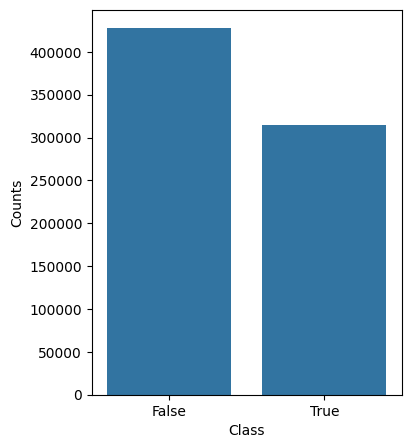

In [130]:
#Visualizations 

class_counts = np.bincount(df["Parkinsons"])

plt.figure(figsize=(4,5))
sns.barplot(x = np.unique(df["Parkinsons"]), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [131]:
#Importing modules
from sklearn.model_selection import train_test_split
import lightgbm as lgb

In [132]:
#Defining the features and labels for dataset 
y = df["Parkinsons"]

X = df.drop(columns=["Parkinsons", "Gender_Male", "Hand", "Direction"])

In [133]:
#Oversampling the minority class in PD
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Assume X and y are your features and labels
print("Original class distribution:", Counter(y))

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled class distribution:", Counter(y_resampled))

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, random_state=42, test_size=0.3)



Original class distribution: Counter({False: 427655, True: 314750})


/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Resampled class distribution: Counter({False: 314750, True: 314750})


In [134]:
print(X_train.columns.tolist())

['HoldTime', 'LatencyTime', 'FlightTime']


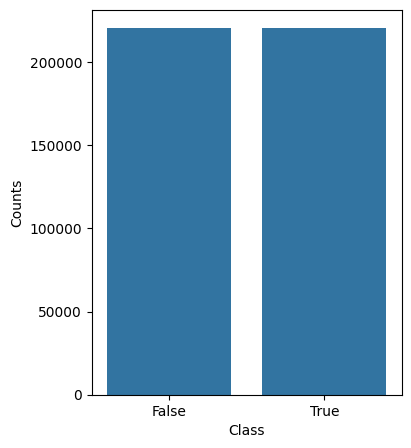

In [135]:
#Visualizations of the PD class after SMOTE
import numpy as np
class_counts = np.bincount(y_train)

plt.figure(figsize=(4, 5))
sns.barplot(x = np.unique(y_train), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [136]:
#Balancing weights

from sklearn.utils import compute_class_weight
import numpy as np

weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))



In [137]:
#Defining hyperparameters in dict-like form

model_lgbm = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    class_weight = class_weight_dict,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.1)

In [138]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [139]:
#Fitting the model, training and performing evaluation

model_lgbm.fit(X_train, y_train)

model_lgbm.predict_proba(X_test)

pred = model_lgbm.predict(X_test)

score = model_lgbm.score(X_train, y_train)

acc_score = accuracy_score(y_test, pred)


In [140]:
acc_score

0.6137516547524491

In [141]:
print("Accuracy on the train set", score)

print("Accuracy on the test set", model_lgbm.score(X_test, y_test))

Accuracy on the train set 0.6159673210030636
Accuracy on the test set 0.6137516547524491


In [142]:
#Confusion matrix and classification matrix
cm = confusion_matrix(y_test, pred)
print(cm)

class_report = classification_report(y_test, pred)
print(class_report)

[[55939 38368]
 [34575 59968]]
              precision    recall  f1-score   support

       False       0.62      0.59      0.61     94307
        True       0.61      0.63      0.62     94543

    accuracy                           0.61    188850
   macro avg       0.61      0.61      0.61    188850
weighted avg       0.61      0.61      0.61    188850



<Axes: title={'center': 'Plot of feature importance'}, xlabel='Feature importance', ylabel='Features'>

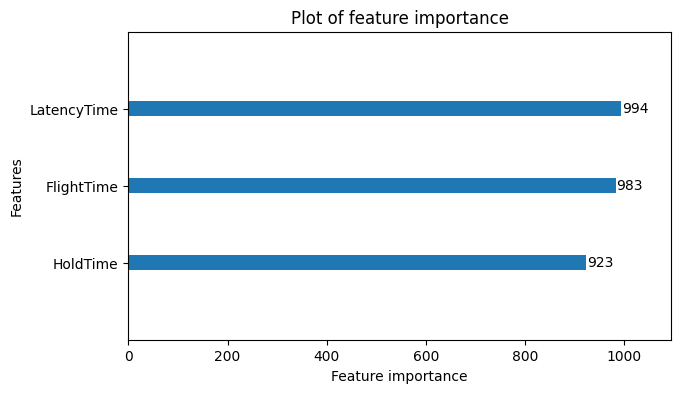

In [143]:
#Plotting important features
lgb.plot_importance(model_lgbm, title="Plot of feature importance", figsize=(7,4), grid=False )

In [144]:
model_lgbm.feature_importances_

array([923, 994, 983], dtype=int32)

Text(0.5, 1.0, 'ROC plot')

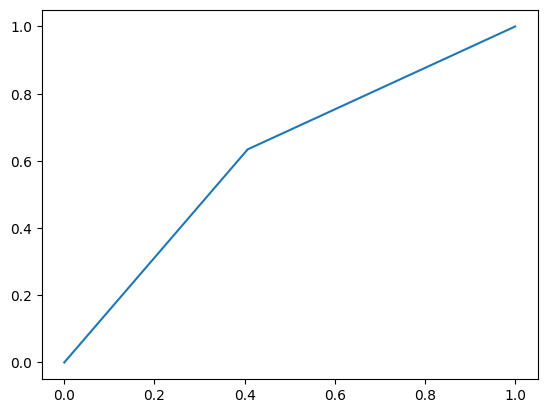

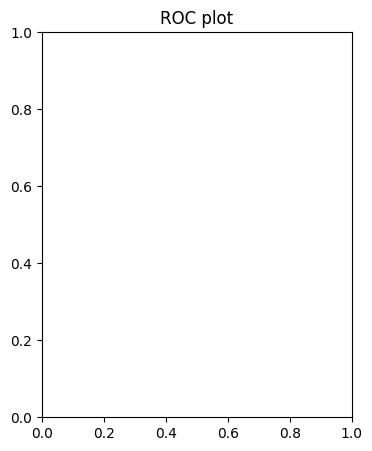

In [145]:
#Plotting roc-curve

from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, pred)

sns.lineplot(x=fpr, y=tpr)

plt.figure(figsize=(4,5))

plt.title("ROC plot")

Retraining the model with only the most impactful features, so dropping hand and direction

In [146]:
df_new = df.drop(columns = ["Hand", "Gender_Male", "Direction"])

In [147]:
df_new

,HoldTime,LatencyTime,FlightTime,Parkinsons
0,78.1,289.1,195.3,True
1,130.9,220.7,175.8,True
2,85.9,257.8,171.9,False
3,78.1,226.6,132.8,True
4,117.2,171.9,93.8,False
...,...,...,...,...
742400,109.4,312.5,218.8,True
742401,93.8,218.8,125.0,True
742402,78.1,265.6,187.5,False
742403,109.4,296.9,203.1,True


In [148]:
#Defining labels and features, and input vectors
from imblearn.over_sampling import SMOTE

y_final = df_new["Parkinsons"]

X_final = df_new.drop(columns=["Parkinsons"])

X_train_new, X_test_final, y_train_new, y_test_final = train_test_split(X_final, y_final, random_state=42, test_size=0.2)

smote_final = SMOTE(random_state = 42)

X_train_final, y_train_final = smote_final.fit_resample(X_train_new, y_train_new)

/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [149]:
print("Train columns:", X_train_final.columns.tolist())
print("Test columns:", X_test_final.columns.tolist())

Train columns: ['HoldTime', 'LatencyTime', 'FlightTime']
Test columns: ['HoldTime', 'LatencyTime', 'FlightTime']


In [150]:
model_final = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.5, verbose=-1)

In [151]:
#Fitting the model, evaluating the model, 
model_final.fit(X_train_final, y_train_final)

final_pred = model_final.predict(X_test_final)

score_final = model_final.score(X_train_final, y_train_final)


In [152]:
#Printing the evalutaion metrics
print(accuracy_score(y_test_final, final_pred))
print()

print(confusion_matrix(y_test_final, final_pred))
print()

print(classification_report(y_test_final, final_pred))
print()

0.6226385867552078

[[53344 32250]
 [23781 39106]]

              precision    recall  f1-score   support

       False       0.69      0.62      0.66     85594
        True       0.55      0.62      0.58     62887

    accuracy                           0.62    148481
   macro avg       0.62      0.62      0.62    148481
weighted avg       0.63      0.62      0.62    148481




Hyperparameter tuning with RandomizedSearchCV since the dataset is large 

In [153]:
from sklearn.model_selection import RandomizedSearchCV, KFold

In [154]:
#Cross validation 
kfold = KFold(n_splits=5, random_state = 42, shuffle=True)

param_grid = {
    "num_leaves": np.arange(20,80,10).tolist(),
    "max_depth": np.arange(4, 12, 4).tolist(),
    "learning_rate": [0.01, 0.05, 0.1],
    "feature_fraction": [0.7, 0.8,0.9],
    "bagging_fraction":[0.7, 0.8, 0.9],
    "min_child_samples": [10, 20, 50],
    "min_split_gain": [0.0, 0.01, 0.1],

}

grid = RandomizedSearchCV(estimator=model_final, param_distributions=param_grid, cv=kfold)

In [155]:
grid.fit(X_train_final, y_train_final)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LGBMClassifier(force_col_wise=True,
                                            learning_rate=0.5, max_depth=6,
                                            num_leaves=30, objective='binary',
                                            verbose=-1),
                   param_distributions={'bagging_fraction': [0.7, 0.8, 0.9],
                                        'feature_fraction': [0.7, 0.8, 0.9],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 8],
                                        'min_child_samples': [10, 20, 50],
                                        'min_split_gain': [0.0, 0.01, 0.1],
                                        'num_leaves': [20, 30, 40, 50, 60, 70]})

In [156]:
#Pulling the best hyperparamters

grid_best = grid.best_params_
grid.best_score_

0.6169805982431292

In [157]:
#Training new model based on hyperparamters from RSCV

model =  lgb.LGBMClassifier(objective= "binary",
    num_leaves = grid_best["num_leaves"],
    min_split_gain = grid_best["min_split_gain"],
    min_child_samples = grid_best["min_child_samples"],
    force_col_wise = True,
    max_depth = grid_best["max_depth"],
    learning_rate = grid_best["learning_rate"],
    feature_fraction = grid_best["feature_fraction"],
    bagging_fraction = grid_best["bagging_fraction"],
    n_estimators= 100)

In [158]:
#Fitting and making predictions on test data
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(accuracy_score(y_test, predictions))


0.6168175800900185


In [159]:
#Confusion matrix and classification report

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))

[[57922 36385]
 [35979 58564]]
              precision    recall  f1-score   support

       False       0.62      0.61      0.62     94307
        True       0.62      0.62      0.62     94543

    accuracy                           0.62    188850
   macro avg       0.62      0.62      0.62    188850
weighted avg       0.62      0.62      0.62    188850



Text(0.5, 1.0, 'ROC plot')

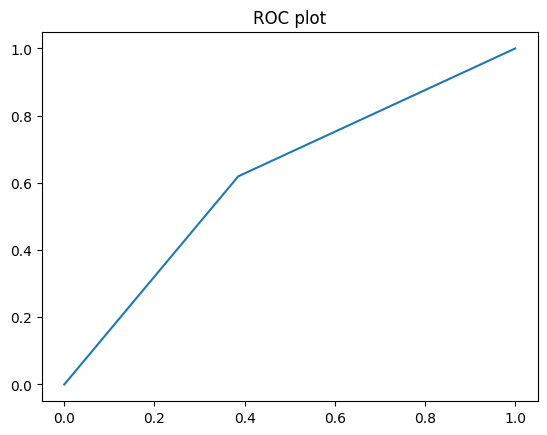

In [160]:
#Visualizations and plotting  roc
fpr, tpr, threshold = roc_curve(y_test, predictions)

sns.lineplot(x=fpr, y=tpr,)

plt.title("ROC plot")